**Table of contents**<a id='toc0_'></a>    
- [Fingerprints of 1 fluorophore](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [Bleaching rate data](#toc1_1_1_)    
    - [ON to OFF data](#toc1_1_2_)    
    - [OFF to ON data](#toc1_1_3_)    
  - [Figure](#toc1_2_)    
    - [Preparation](#toc1_2_1_)    
    - [Figure](#toc1_2_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Fingerprints of 1 fluorophore](#toc0_)

In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

## <a id='toc1_1_'></a>[Reading data](#toc0_)

### <a id='toc1_1_1_'></a>[Bleaching rate data](#toc0_)

In [2]:
identifiers = ['1e1', '1e2', '1e3', '1e4']
bleaching_times_all_A = []
fingerprints_all_A = []
total_photons_A = []

for _ in identifiers:
    fingerprints_all_A.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    total_photons_A.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\bl_rate"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_A.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all_A[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                total_photons_A[identifiers.index(id)] += pd.read_parquet(file).sum(axis=0).values.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_A):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_A[i] = fingerprint

In [3]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_A = []
for fingerprint in fingerprints_all_A:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_A.append([param.value for param in result.params.values()])

### <a id='toc1_1_2_'></a>[ON to OFF data](#toc0_)

In [2]:
identifiers = ['red1', 'red01', 'red005', 'red001']
bleaching_times_all_B = []
fingerprints_all_B = []
ON_periods_B_frames = []

for _ in identifiers:
    fingerprints_all_B.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    ON_periods_B_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_prob"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_B.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_B[identifiers.index(id)] += data.sum(axis=1)
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    ON_periods_B_frames[identifiers.index(id)] += blinks.on_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_B):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_B[i] = fingerprint

In [5]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_B = []
for fingerprint in fingerprints_all_B:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_B.append([param.value for param in result.params.values()])

### <a id='toc1_1_3_'></a>[OFF to ON data](#toc0_)

In [6]:
identifiers = ['2e-2', '2e-1', '2e0', '2e1']
bleaching_times_all_C = []
fingerprints_all_C = []
OFF_periods_C_frames = []

for _ in identifiers:
    fingerprints_all_C.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    OFF_periods_C_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_time"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_C.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_C[identifiers.index(id)] += data.sum(axis=1)
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    OFF_periods_C_frames[identifiers.index(id)] += blinks.off_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_C):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_C[i] = fingerprint

In [7]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_C = []
for fingerprint in fingerprints_all_C:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_C.append([param.value for param in result.params.values()])

## <a id='toc1_2_'></a>[Figure](#toc0_)

### <a id='toc1_2_1_'></a>[Preparation](#toc0_)

In [8]:
total_photons_A = [np.array(total_photons) for total_photons in total_photons_A]
minimum = np.min([np.min(a) for a in total_photons_A])
if minimum == 0:
    minimum = 1
maximum = np.max([np.max(a) for a in total_photons_A])
log_bins_A = np.logspace(np.log10(minimum), np.log10(maximum), 50)

In [9]:
# ON periods in seconds
ON_periods_B = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_B_frames]

In [10]:
# OFF periods in seconds
OFF_periods_C = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_C_frames]
minimum = np.min([np.min(a) for a in OFF_periods_C])
maximum = np.max([np.max(a) for a in OFF_periods_C])
log_bins_C = np.logspace(np.log10(minimum), np.log10(maximum), 50)

In [11]:
weights_B = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_B]
weights_C = [np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_C]
weights_A = [np.ones_like(total_photons) / total_photons.size for total_photons in total_photons_A]

### <a id='toc1_2_2_'></a>[Figure](#toc0_)

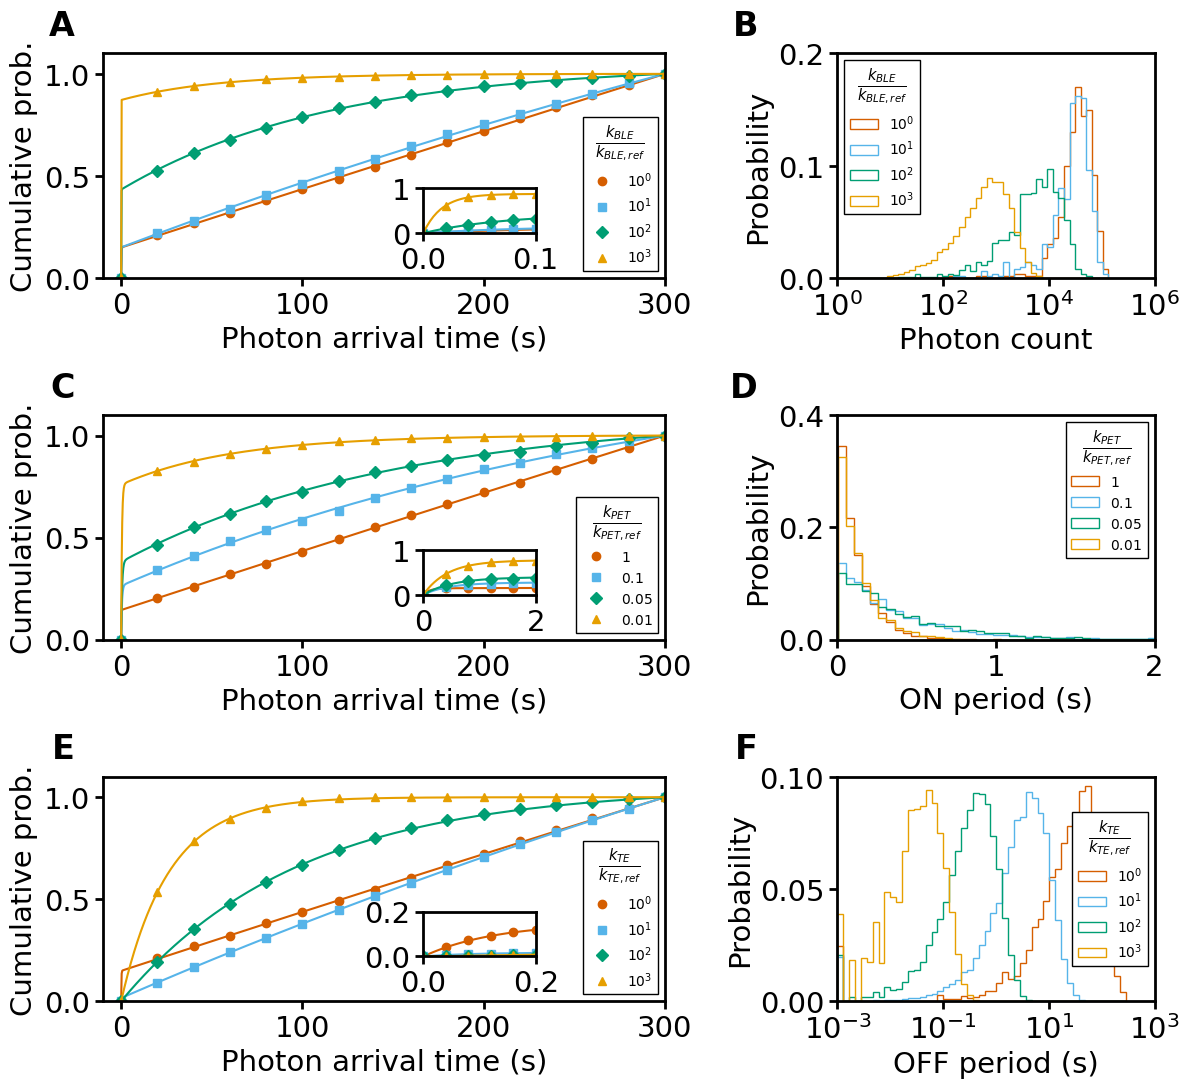

In [17]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

def plot_figure3(ax, labels, data, fit, legendtitle, xlim2, ylim2, spacing2, colors=colors):
    markers = ['o', 's', 'D', '^']
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(ylabel='Cumulative prob.', xlabel='Photon arrival time (s)', legend=True,
                        xlim=[-10, 300], ylim=[0, 1.1])
    for (fingerprint, parameters, label, color, marker) in zip(data, fit, labels, colors, markers):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(data=[fingerprint.index[::spacing1], fingerprint[::spacing1]], label=label, color=color, marker=marker, linestyle='', axes=ax)
        fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], color=color, axes=ax)
    fi.universal_figure(axes=ax, legendargs=dict(title=legendtitle, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), **description)

    inset = ax.inset_axes([0.57, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for (fingerprint, parameters, label, color, marker) in zip(data, fit, labels, colors, markers):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(data=[fingerprint.index[::spacing2], fingerprint[::spacing2]], axes=inset, label=label, color=color, marker=marker, linestyle='')
        fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=inset, color=color)
    inset.set_ylabel('')
    inset.set_xlabel('')


import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['axes.linewidth'] = 2
gs = plt.GridSpec(3, 5)
fig = plt.figure(figsize=(12, 11))
ax1 = fig.add_subplot(gs[0, 0:3])
labels1 = [r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$']
legendtitle1 = r'$\frac{k_{BLE}}{k_{BLE,ref}}$'
plot_figure3(ax1, labels1, fingerprints_all_A, parameters_all_fit_cdf_A, legendtitle1, 0.1, 1, 20)
ax2 = fig.add_subplot(gs[0, 3:])
fi.universal_figure(type_='hist', data=list(reversed(total_photons_A)), axes=ax2, density=False, histtype='step',
                    label=list(reversed(labels1)), color=list(reversed(colors)), alpha=1, weights=list(reversed(weights_A)), xscale='log',
                    bins=log_bins_A, ylim=[0, 0.2], xlim=[1e0, 1e6],
                    ylabel='Probability', xlabel='Photon count',
                    legend=True, legendargs=dict(title=legendtitle1, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15))
ax3 = fig.add_subplot(gs[1, 0:3])
labels3 = [r'$1$', r'$0.1$', r'$0.05$', r'$0.01$']
legendtitle3 = r'$\frac{k_{PET}}{k_{PET,ref}}$'
plot_figure3(ax3, labels3, fingerprints_all_B, parameters_all_fit_cdf_B, legendtitle3, 2, 1, 400)
ax4 = fig.add_subplot(gs[1, 3:])
fi.universal_figure(type_='hist', data=list(reversed(ON_periods_B)), axes=ax4, density=False,
                    label=list(reversed(labels3)), color=list(reversed(colors)), alpha=1, weights=list(reversed(weights_B)),
                    ylabel='Probability', xlabel='ON period (s)', histtype='step', bins=60,
                    legend=True, legendargs=dict(title=legendtitle3, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), ylim=[0, 0.4], xlim=[0, 2])
ax5 = fig.add_subplot(gs[2, 0:3])
labels5 = [r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$']
legendtitle5 = r'$\frac{k_{TE}}{k_{TE,ref}}$'
plot_figure3(ax5, labels5, fingerprints_all_C, parameters_all_fit_cdf_C, legendtitle5, 0.2, 0.2, 40)
ax6 = fig.add_subplot(gs[2, 3:])
fi.universal_figure(type_='hist', data=list(reversed(OFF_periods_C)), axes=ax6, density=False, histtype='step',
                    label=list(reversed(labels5)), color=list(reversed(colors)), alpha=1, xscale='log', bins=log_bins_C,
                    ylabel='Probability', xlabel='OFF period (s)', weights=list(reversed(weights_C)),
                    legend=True, legendargs=dict(title=legendtitle5, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), ylim=[0, 0.1], xlim=[1e-3, 1e3])
axes = fig.get_axes()
for i, (axis, letter) in enumerate(zip(axes, ['A', 'B', 'C', 'D', 'E', 'F'])):
    offset = -0.05
    if i % 2 != 0:
        offset = -0.25
    axis.text(offset, 1.05, letter, transform=axis.transAxes, fontsize=24, fontweight='bold', va='bottom', ha='right')
fig.tight_layout()
fig.savefig('fingerprint_1f.png', dpi=300, bbox_inches='tight', pad_inches=0.1)